In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [2]:
data = pd.read_csv("SuperStore_Sales_Dataset.csv")

In [5]:
data = data[['Order Date','Sales']]

In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True)

In [11]:
data.set_index('Order Date', inplace=True)

In [13]:
data.head(5)

,Sales
Order Date,
2019-01-01,73.94
2019-01-02,173.94
2019-01-02,231.98
2019-01-03,114.46
2019-01-03,30.08


In [15]:
daily_Sales = data.groupby(data.index)['Sales'].sum()

In [19]:
daily_Sales.head(5)

Order Date
2019-01-01      73.940
2019-01-02     405.920
2019-01-03    2095.830
2019-01-04    1069.220
2019-01-05     255.904
Name: Sales, dtype: float64

In [23]:
daily_Sales = daily_Sales.to_frame()  #Creating into a DataFrame as it is easier for ARIMA and understanding os the system 

In [25]:
daily_Sales.head(5)

,Sales
Order Date,
2019-01-01,73.940
2019-01-02,405.920
2019-01-03,2095.830
2019-01-04,1069.220
2019-01-05,255.904


Text(0, 0.5, 'Sales')

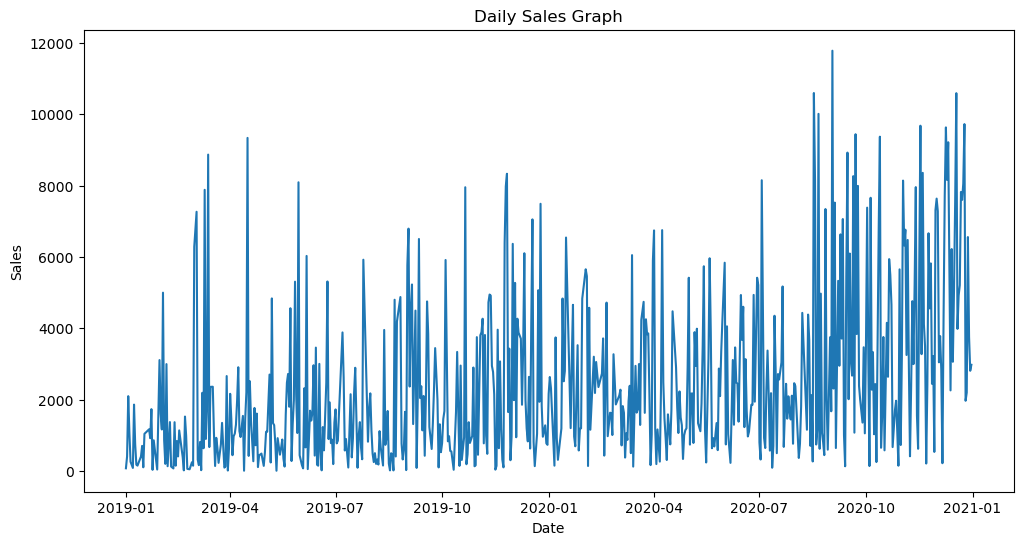

In [33]:
plt.figure(figsize=(12,6))
plt.plot(daily_Sales.index,daily_Sales['Sales'])
plt.title("Daily Sales Graph")
plt.xlabel("Date")
plt.ylabel("Sales")

In [37]:
result = adfuller(daily_Sales['Sales'])

"ADF Statistic:", result[0]
"p-value:", result[1]

('p-value:', 0.184286431239702)

In [41]:
#Here as per the result the p-value is more than 0.05 which means data is stationary 
#which means it has seasonality, trend or instability so we have to make it clean

In [62]:
daily_Sales['Sales_Diff'] = daily_Sales['Sales'].diff()
#1st order differencing

In [72]:
daily_Sales.dropna(inplace=True)

In [74]:
result = adfuller(daily_Sales['Sales_Diff'])

print("p-value:", result[1])

p-value: 4.816873671038216e-23


In [76]:
#So now all the null values are gone data is now clean to do furthur forecasting

Text(0.5, 1.0, 'Differenced Sales')

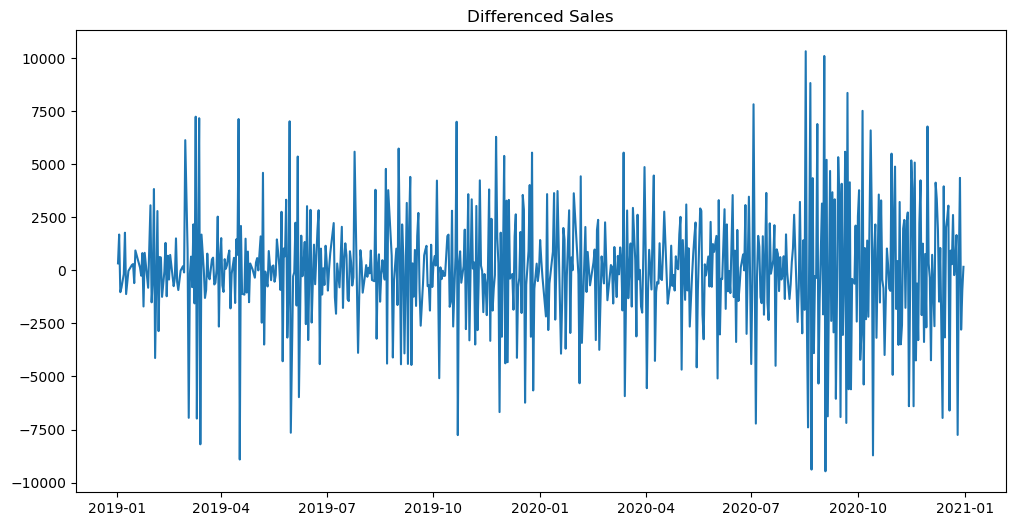

In [78]:
plt.figure(figsize=(12,6))

plt.plot(daily_Sales['Sales_Diff'])
plt.title('Differenced Sales')

In [85]:
#now we will perform ARIMA model

In [102]:
model = ARIMA(daily_Sales['Sales'],order=(1,1,1))
#This is not error this is worning 

C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [104]:
model_fit = model.fit()

In [106]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  642
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5815.990
Date:                Wed, 06 May 2026   AIC                          11637.979
Time:                        23:34:29   BIC                          11651.369
Sample:                             0   HQIC                         11643.176
                                - 642                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0428      0.036      1.205      0.228      -0.027       0.112
ma.L1         -0.9595      0.011    -87.614      0.000      -0.981      -0.938
sigma2      4.438e+06    1.9e+05     23.369      0.000    4.07e+06    4.81e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               205.69
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               2.15   Skew:                             1.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [110]:
forecast = model_fit.forecast(steps = 30)

C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [112]:
forecast

642    4913.568984
643    4996.485153
644    5000.032564
645    5000.184333
646    5000.190826
647    5000.191104
648    5000.191116
649    5000.191116
650    5000.191117
651    5000.191117
652    5000.191117
653    5000.191117
654    5000.191117
655    5000.191117
656    5000.191117
657    5000.191117
658    5000.191117
659    5000.191117
660    5000.191117
661    5000.191117
662    5000.191117
663    5000.191117
664    5000.191117
665    5000.191117
666    5000.191117
667    5000.191117
668    5000.191117
669    5000.191117
670    5000.191117
671    5000.191117
Name: predicted_mean, dtype: float64

In [120]:
future_dates = pd.date_range(start=daily_Sales.index[-1] + pd.Timedelta(days=1),periods=30)
#This has created the numbers into original more 30 days date


In [122]:
future_dates

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10', '2021-01-11', '2021-01-12',
               '2021-01-13', '2021-01-14', '2021-01-15', '2021-01-16',
               '2021-01-17', '2021-01-18', '2021-01-19', '2021-01-20',
               '2021-01-21', '2021-01-22', '2021-01-23', '2021-01-24',
               '2021-01-25', '2021-01-26', '2021-01-27', '2021-01-28',
               '2021-01-29', '2021-01-30'],
              dtype='datetime64[ns]', freq='D')

In [124]:
#Now we will create these dates and forecasting into a dataframe

forecast_data = pd.DataFrame({'Date' : future_dates, 'forecast' : forecast})

In [128]:
forecast_data.head(5)

,Date,forecast
642,2021-01-01,4913.568984
643,2021-01-02,4996.485153
644,2021-01-03,5000.032564
645,2021-01-04,5000.184333
646,2021-01-05,5000.190826


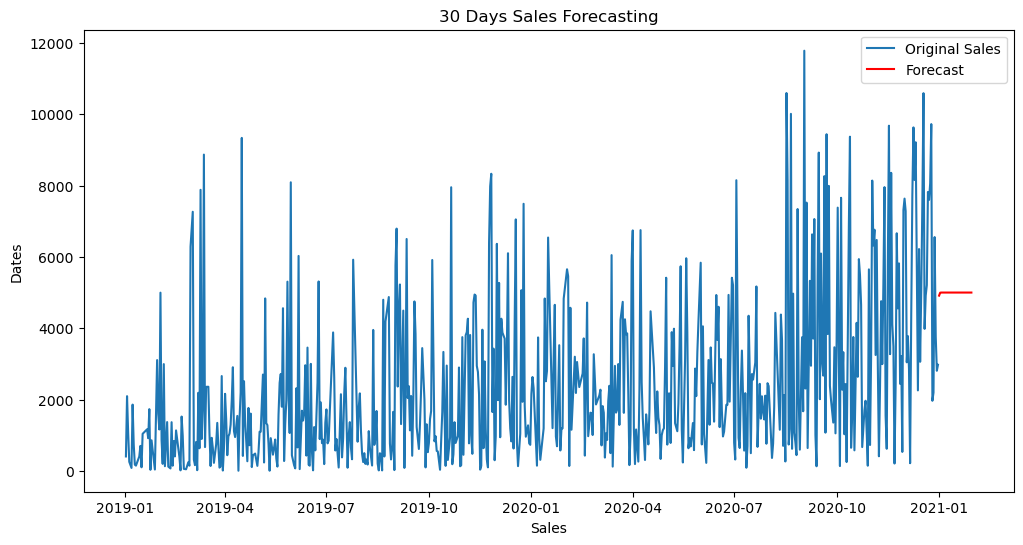

In [134]:
plt.figure(figsize=(12,6))

#Original Sales Graph
plt.plot(daily_Sales.index,
         daily_Sales['Sales'],
         label='Original Sales')

#Forecast Sales Graph
plt.plot(forecast_data['Date'],
         forecast_data['forecast'],
         color='red',
         label='Forecast')

plt.title("30 Days Sales Forecasting")
plt.xlabel('Sales')
plt.ylabel('Dates')

plt.legend()
